# Beyond BLAST

In [1]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()

  Activating project at `~/Desktop/cosmo/notebooks/blast_code`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Manifest.toml`


In [2]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
#include("blast_code/src/new_funcs.jl");

Main.blast_tutorials

In [3]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using FFTW
using FastTransforms
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using StaticArrays
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using NumericalIntegration
using .Blast
using .blast_tutorials;

### Computing background quantities:

redshift $z$, comoving distance $\chi(z)$

In [4]:
# i want to save in a .txt file called "dimensions.txt" the size of all the arrays unsigned
# name of the file is "dimensions.txt"

In [5]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
χ_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)

### Saving array dimensions in "dimensions.txt"

In [6]:
open("dimensions.txt", "w") do f
    write(f, "------------------------ \n")
    write(f, "IMPORTED REDSHIFT\n")
    write(f, "Redshift array z_b taken from background has dimensions: $(size(z_b))\n")
    write(f, "MIN = $(minimum(z_b)) || MAX = $(maximum(z_b)) \n")
    write(f, "------------------------ \n")
    write(f, "IMPORTED COMOVING DISTANCE\n")
    write(f, "Comoving distance array χ_b taken from background has dimensions: $(size(χ_b))\n")
    write(f, "MIN = $(minimum(χ_b)) || MAX = $(maximum(χ_b)) \n")
    write(f, "------------------------ \n")
    write(f, "INTERPOLATED QUANTITIES\n")
    write(f, "Redshift interpolated array z_of_χ has dimensions: $(size(z_of_χ(χ_b)))\n")
    write(f, "MIN = $(minimum(z_of_χ(χ_b))) || MAX = $(maximum(z_of_χ(χ_b))) \n")
    write(f, "Comoving distance interpolated array χ_of_z has dimensions: $(size(χ_of_z(z_b)))\n")
    write(f, "MIN = $(minimum(χ_of_z(z_b))) || MAX = $(maximum(χ_of_z(z_b))) \n")
    write(f, "------------------------ \n")
    write(f, "z_b = z_of_χ(χ_b) and x_b = χ_of_z(z_b), up to numerical precision.\n")
    write(f, "------------------------ \n")
end;

In [7]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
z_n5k = n5k_bins["z_cl"]
z_n5k = sort(z_n5k) # sort the redshift array in ascending order
n_z_matrix = n5k_bins["dNdz_cl"];

In [8]:
open("dimensions.txt", "a") do f
    write(f, "N5K QUANTITIES\n")
    write(f, "n5k_bins has columns: $(keys(n5k_bins))\n")
    write(f, "------------------------ \n")
    write(f, "dN/dz\n")
    write(f, "numerical density N5K dN/dz (for clustering) has dimensions: $(size(n5k_bins["dNdz_cl"]))\n")
    write(f, "MIN = $(minimum(n_z_matrix)) || MAX = $(maximum(n_z_matrix)) \n")
    write(f, "------------------------ \n")
    write(f, "REDSHIFT z\n")
    write(f, "redshift N5K z (for clustering) has dimensions: $(size(n5k_bins["z_cl"]))\n")
    write(f, "MIN = $(minimum(n5k_bins["z_cl"])) || MAX = $(maximum(n5k_bins["z_cl"])) \n")
    write(f, "------------------------ \n")
    write(f, "There are $(size(n5k_bins["z_cl"])[1]) redshift values for each of the $(size(n5k_bins["dNdz_cl"])[2]) bins.\n")
    write(f, "------------------------ \n")
end;

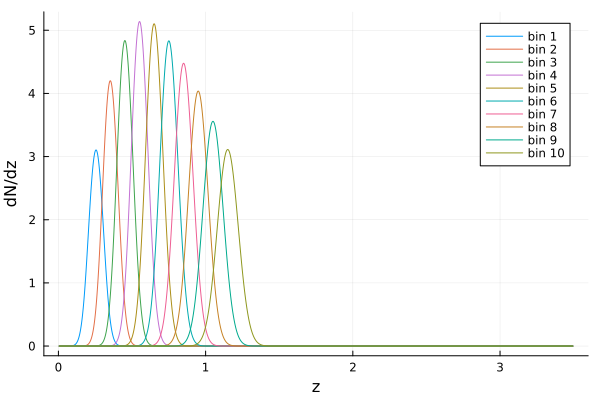

In [9]:
p = plot()
for i in 1:size(n_z_matrix, 2)
    plot!(p, z_n5k, n_z_matrix[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
display(p)

### Normalizing n(z)

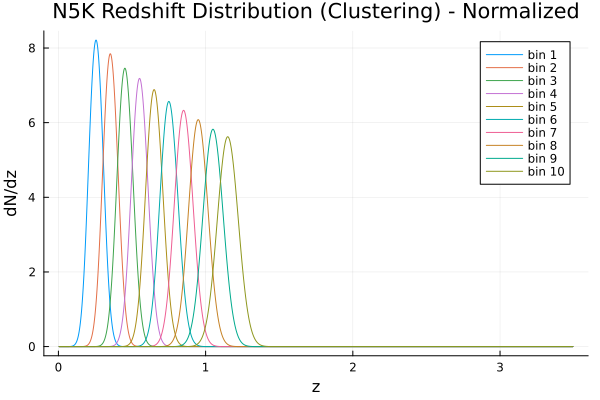

In [10]:
norms = [quadgk(x -> DataInterpolations.AkimaInterpolation(n_z_matrix[:, i], z_n5k, extrapolation=ExtrapolationType.Linear)(x),
                minimum(z_n5k), maximum(z_n5k))[1] for i in 1:size(n_z_matrix, 2)]
n_z_norm = n_z_matrix ./ reshape(norms, 1, :);
#### PLOTTING the results
p = plot()
for i in 1:size(n_z_norm, 2)
    plot!(p, z_n5k, n_z_norm[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
title!(p, "N5K Redshift Distribution (Clustering) - Normalized")
display(p)

In [11]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "N5K dN/dz normalization\n")
    write(f, "The N5K dN/dz values for each bin are normalized such that the integral over redshift is 1.\n")
    write(f, "The norms used for normalization are: \n$(norms)\n")
    write(f, "------------------------ \n")
    write(f, "The normalized N5K dN/dz values for each bin have dimensions: \n$(size(n_z_norm))\n")
    write(f, "MIN = $(minimum(n_z_norm)) || MAX = $(maximum(n_z_norm)) \n")
end;

In [12]:
#### REDSHIFT ARRAY
z_array = LinRange(minimum(z_n5k), maximum(z_n5k), size(z_n5k)[1]) # array of redshifts to evaluate n(z) on
#### COMOVING DISTANCES ARRAY
chi_array = χ_of_z.(z_array); # array of comoving distances corresponding to z_range

In [13]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "REDSHIFT ARRAY\n")
    write(f, "Redshift z_array is a vector or dimension: $(size(z_array))\n")
    write(f, "MIN = $(minimum(z_array)) || MAX = $(maximum(z_array))\n")
    write(f, "------------------------ \n")
    write(f, "COMOVING DISTANCE ARRAY\n")
    write(f, "Comoving distance chi_array is a vector or dimension: $(size(chi_array))\n")
    write(f, "MIN = $(minimum(chi_array)) || MAX = $(maximum(chi_array))\n")
    write(f, "------------------------ \n")
    write(f, "Values of normalized N5K dN/dz (clustering) for the first bin are: \n$(n_z_norm[:, 1])\n")
    write(f, "------------------------ \n")
end;

In [14]:
cosmo = Blast.FlatΛCDM()
n_chi = 10;                  # Number of comoving distance points

In [15]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "NUMBER OF COMOVING DISTANCE POINTS: $n_chi\n")
end;

In [16]:
# Array of comoving distances
x_array = LinRange(26, 7000, n_chi)
# Array of redshifts corresponding to the comoving distances
z_range = z_of_χ.(x_array);

In [17]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "COMOVING DISTANCES AND CORRESPONDING REDSHIFTS\n")
    write(f, "Array of comoving distances x_array has dimensions: $(size(x_array))\n")
    write(f, "MIN = $(minimum(x_array)) || MAX = $(maximum(x_array)) \n")
    write(f, "Array of redshifts z_range has dimensions: $(size(z_range))\n")
    write(f, "MIN = $(minimum(z_range)) || MAX = $(maximum(z_range)) \n")
    write(f, "------------------------ \n")
end;

In [18]:
###### BIAS ######
# compute the bias. the equation is b(z) = b_0 * sqrt(1+z). we set b_0 = 1.0.!
b_0 = 1.0
b_z_array = b_0 .* sqrt.(1 .+ z_range); # bias as a function of redshift

In [19]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "BIAS ARRAY\n")
    write(f, "Array of bias values b_z_array has dimensions: $(size(b_z_array))\n")
    write(f, "MIN = $(minimum(b_z_array)) || MAX = $(maximum(b_z_array)) \n")
  end;

In [20]:
###### GROWTH FACTOR ######
#i want to obtain the growth factor D(z) from the background quantities. i can use the cosmology package to compute this.
function heath_integral(cosmo, z)
    integrand(zp) = (1.0 + zp) / (Blast.compute_adimensional_hubble_factor(zp, cosmo)^3)
    integral_val, _ = quadgk(integrand, z, Inf, rtol=1e-8)
    return Blast.compute_adimensional_hubble_factor(z, cosmo) * integral_val
end
function compute_growth_factor(cosmo, z_range)
    D_unnorm_z0 = heath_integral(cosmo, 0.0)
    D_array = [heath_integral(cosmo, zz) / D_unnorm_z0 for zz in z_range]
    return D_array
end
# Array of growth factor values
growth_array = compute_growth_factor(cosmo, z_range);

In [21]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "GROWTH FACTOR ARRAY\n")
    write(f, "Array of growth factor values D_z_array has dimensions: $(size(growth_array))\n")
    write(f, "MIN = $(minimum(growth_array)) || MAX = $(maximum(growth_array)) \n")
  end;

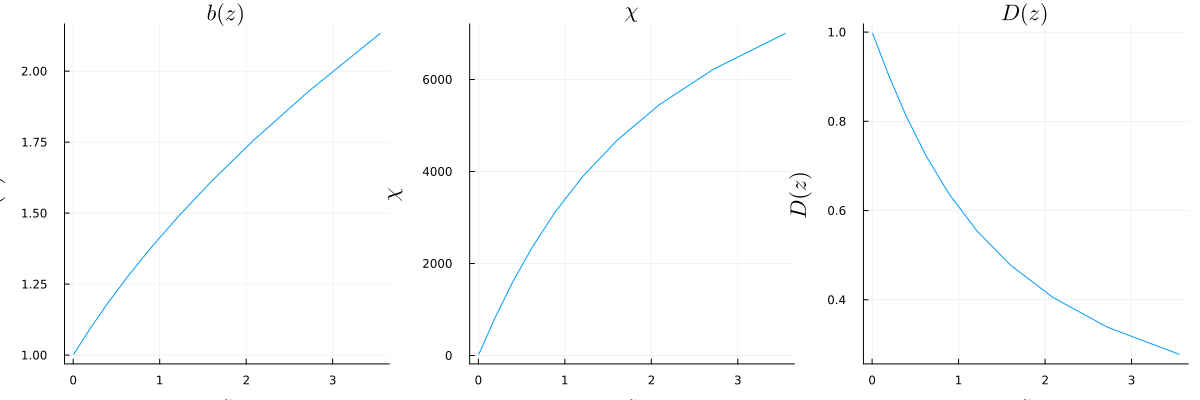

In [22]:
p1 = plot(z_range, 
          b_z_array, 
          label=L"$b(z)$", 
          xlabel=L"$z$", 
          ylabel=L"$b(z)$", 
          title=L"$b(z)$")
p2 = plot(z_range, 
          x_array, 
          label=L"z and $\chi$",
          title = L"$\chi$",
          xlabel=L"$z$", 
          ylabel=L"$\chi$")
p3 = plot(z_range, 
          growth_array, 
          label="Growth Factor D(z)", 
          xlabel=L"$z$", 
          ylabel=L"$D(z)$", 
          title=L"$D(z)$")
plot(p1, p2, p3, layout=(1,3), titlefontsize=15, labelfontsize=15, legendfontsize=15, size=(1200,400), legend=false)


In [23]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Array of redshifts: z_range has dimensions: $(size(z_range)) || z_array has dimensions: $(size(z_array))\n")
  end;

In [24]:
n_bins = size(n_z_norm, 2) # number of tomographic bins
nz = zeros(n_chi, n_bins) # size nx per number of bins
for b in 1:n_bins
     nz_func = DataInterpolations.AkimaInterpolation(n_z_norm[:, b], z_array, extrapolation=ExtrapolationType.Linear)
     nz_norm, _ = quadgk(nz_func, minimum(z_range), maximum(z_range), rtol=1e-8)
     #println("Bin $b: Normalized n(z) integral: ", nz_norm)
     nz[:, b] = nz_func.(z_range)
     #println("Bin $b: n(z) has size: ", size(nz))
end
 

In [25]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Number of tomographic bins: $(n_bins)\n")
    write(f, "Size of n(z) array nz: $(size(nz))\n")
  end;

In [26]:
prefac = x_array.^2 .* b_z_array .* growth_array
kernel_composed = reshape(prefac, :, 1) .* nz;

In [27]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Number of tomographic bins n_bins: $(n_bins)\n")
    write(f, "Size of n(z) array nz: $(size(nz))\n")
    write(f, "Size of prefactor array (chi^2 * b(z) * D(z)): $(size(prefac))\n")
    write(f, "Size of kernel_composed array: $(size(kernel_composed))\n")
    write(f, "The prefactor array is the product of chi^2, b(z), and D(z) evaluated at the redshifts corresponding to the comoving distances in x_array.\n")
    write(f, "Size of array z_range: $(size(z_range))\n")
    write(f, "Size of array x_array: $(size(x_array))\n")
    write(f, "Size of array b_z_array: $(size(b_z_array))\n")
    write(f, "Size of array growth_array: $(size(growth_array))\n")
    write(f, "Size of array nz: $(size(nz))\n")
  end;

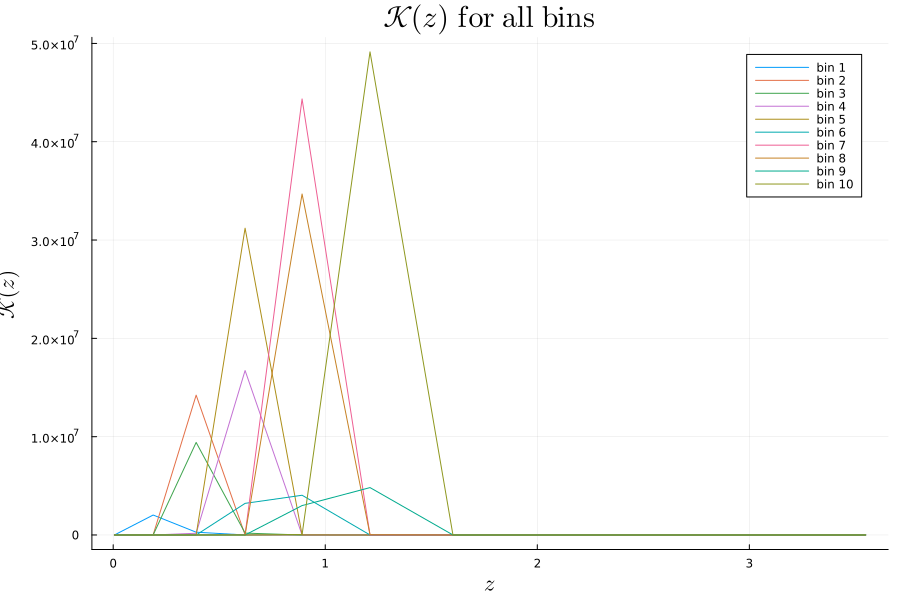

In [28]:
p = plot(
    xlabel=L"$z$",
    ylabel=L"\mathcal{K}(z)",
    title=L"\mathcal{K}(z)\ \mathrm{for\ all\ bins}",
    xlabelfontsize=15,
    ylabelfontsize=15,
    titlefontsize=20,
    legendfontsize=8,
    size=(900, 600)
)
for b in 1:size(kernel_composed, 2)
    plot!(p, z_range, kernel_composed[:, b], label="bin $b")
end
display(p)

In [29]:
ℓ = Blast.ℓ
x_min = 26                                            # minimum comoving distance
x_max = 7000                                          # maximum comoving distance
χ = LinRange(x_min, x_max, n_chi)                     # array of comoving distances
R = chebpoints(n_chi, -1, 1)                          # array of ratios between comoving distances
R = reverse(R[R.>0])
nR = length(R)                                        # number of ratios R
kmax = 200/13                                         # maximum wavenumber (small scales)
kmin = 2.5/x_max                                      # minimum wavenumber (large scales)
n_cheb = 120                                          # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^(15)+1;                                         # number of integration points
k_array = k1_array = k2_array = 10 .^ chebpoints(n_cheb, log10(kmin), log10(kmax)); # wavenumbers k' and k'' on Chebyshev grid

# Define k' and k'' on Chebyshev grid
#k1 = k2 = 10 .^ chebpoints(n_cheb, log10(kmin), log10(kmax)) # wavenumbers k' and k''

In [30]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "INPUT PARAMETERS \n")
    write(f, "MIN COMOVING DISTANCE = $x_min, MAX COMOVING DISTANCE = $x_max, \n")
    write(f, "NUMBER OF COMOVING DISTANCE POINTS = $n_chi, \n")
    write(f, "NUMBER OF RATIOS R = $nR, \n")
    write(f, "MIN RATIO Rmin = $(minimum(R)), MAX RATIO Rmax = $(maximum(R)), \n")
    write(f, "MIN WAVENUMBER kmin = $kmin, MAX WAVENUMBER kmax = $kmax, \n")
    write(f, "NUMBER OF CHEBYSHEV NODES = $n_cheb, \n")
    write(f, "NUMBER OF INTEGRATION POINTS = $N, \n")
    write(f, "EXPONENT β = -2 for shear-shear, 0 for galaxy-shear and 2 for galaxy-galaxy \n")
  end;

In [31]:
# I choose a grid of Chebyshev nodes in z, which I will use to evaluate 
# the kernels and the power spectrum.
zmin = minimum(z_range)
zmax = maximum(z_range)

t_of_z(z) = (2*z - (zmax + zmin)) / (zmax - zmin)
z_of_t(t) = (zmin + zmax)/2 + (zmax - zmin)/2 * t

j = 1:n_cheb
#t_nodes = cos.((2 .* j .- 1) .* pi ./ (2*n_cheb))     # size N, in [-1,1]
t_nodes = [cos(π * k / (n_cheb - 1)) for k in 0:n_cheb-1]
z_nodes = @. zmin + (zmax - zmin) / 2 * (1 + t_nodes);
#z_nodes = z_of_t.(t_nodes);                            # Chebyshev nodes in z

In [32]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "REDSHIFT GRID")
    write(f, "MIN REDSHIFT = $zmin, MAX REDSHIFT = $zmax, \n")
    write(f, "Dimension of z_nodes = $n_cheb \n")
    write(f, "Dimension of t_nodes = $n_cheb \n")
    write(f, "MIN Chebyshev node in z: $(z_nodes[1]), MAX Chebyshev node in z: $(z_nodes[end]) \n")
    write(f, "MIN Chebyshev node in t: $(t_nodes[1]), MAX Chebyshev node in t: $(t_nodes[end]) \n")
  end;

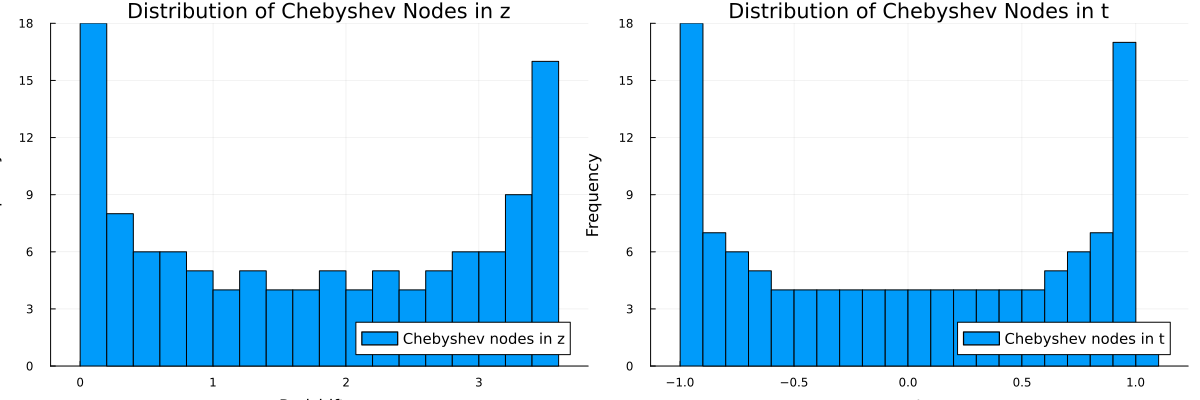

In [33]:
h1 = histogram(z_nodes, bins=20, 
               label="Chebyshev nodes in z", 
               xlabel="Redshift z", 
               ylabel="Frequency", 
               title="Distribution of Chebyshev Nodes in z",
               legendfontsize=10,
               legend=:bottomright)
h2 = histogram(t_nodes, bins=20, 
               label="Chebyshev nodes in t", 
               xlabel="t", 
               ylabel="Frequency", 
               title="Distribution of Chebyshev Nodes in t",
               legendfontsize=10,
               legend=:bottomright)
plot(h1, h2, layout=(1,2), size=(1200,400))

In [34]:
chi_interp    = AkimaInterpolation(x_array, z_range, extrapolation=ExtrapolationType.Linear)
bias_interp   = AkimaInterpolation(b_z_array, z_range, extrapolation=ExtrapolationType.Linear)
growth_interp = AkimaInterpolation(growth_array, z_range, extrapolation=ExtrapolationType.Linear)
# nz has shape (96, 10); build one interpolator per tomographic bin
nz_interp = [AkimaInterpolation(nz[:, i], z_range,
                                 extrapolation=ExtrapolationType.Linear)
             for i in 1:n_bins];
K_vals = zeros(n_cheb, n_bins)
for i in 1:n_bins
    for k in 1:n_cheb
        z  = z_nodes[k]
        χ  = chi_interp(z)
        b  = bias_interp(z)
        D  = growth_interp(z)
        ni = max(0.0, nz_interp[i](z))   # clamp fisico
        K_vals[k, i] = χ^2 * b * D * ni
    end
end
# ── 6. Plan the DCT-I (REDFT00) once, reuse for all bins ────────────────────
#       plan_fft mirrors the BLAST helper exactly
function plan_fft_1d(vals::AbstractVector)
    kind = size(vals, 1) > 1 ? FFTW.REDFT00 : FFTW.DHT
    p = FFTW.plan_r2r(deepcopy(vals), kind, [1];
                      flags=FFTW.PATIENT, timelimit=Inf)
    return p
end
function fast_chebcoefs_1d(vals::AbstractVector, plan::FFTW.r2rFFTWPlan)
    coefs = plan * vals
    N = length(coefs)
    coefs ./= 2 * (N - 1)          # normalise
    coefs[2:end-1] .*= 2           # double interior coefficients
    return coefs
end

plan = plan_fft_1d(K_vals[:, 1]);   # plan built on a single column (n_cheb elements)

# ── 7. Compute Chebyshev coefficients  c[bin, node_index] ───────────────────
#       Shape: (n_bins, n_cheb)  →  c_n^(i) for bin i, order n
cheb_coeff_K = zeros(n_bins, n_cheb)

for i in 1:n_bins
    cheb_coeff_K[i, :] = fast_chebcoefs_1d(K_vals[:, i], plan)
end

In [35]:
open("dimensions.txt", "a") do f
    write(f, "------------------------\n")
    write(f, "CHEBYSHEV DECOMPOSITION OF WINDOW KERNEL K(z)\n")
    write(f, "K(z) = chi^2(z) * b(z) * D(z) * n(z)\n")
    write(f, "Number of Chebyshev nodes n_cheb = $n_cheb\n")
    write(f, "Chebyshev nodes in t: t_nodes has dimension $(size(t_nodes))\n")
    write(f, "MIN t = $(minimum(t_nodes)) || MAX t = $(maximum(t_nodes))\n")
    write(f, "Chebyshev nodes in z: z_nodes has dimension $(size(z_nodes))\n")
    write(f, "MIN z = $(minimum(z_nodes)) || MAX z = $(maximum(z_nodes))\n")
    write(f, "K_vals shape (n_cheb × n_bins) = $(size(K_vals))\n")
    write(f, "cheb_coeff_K shape (n_bins × n_cheb) = $(size(cheb_coeff_K))\n")
    write(f, "MIN coeff = $(minimum(cheb_coeff_K)) || MAX coeff = $(maximum(cheb_coeff_K))\n")
    write(f, "------------------------\n")
end

25

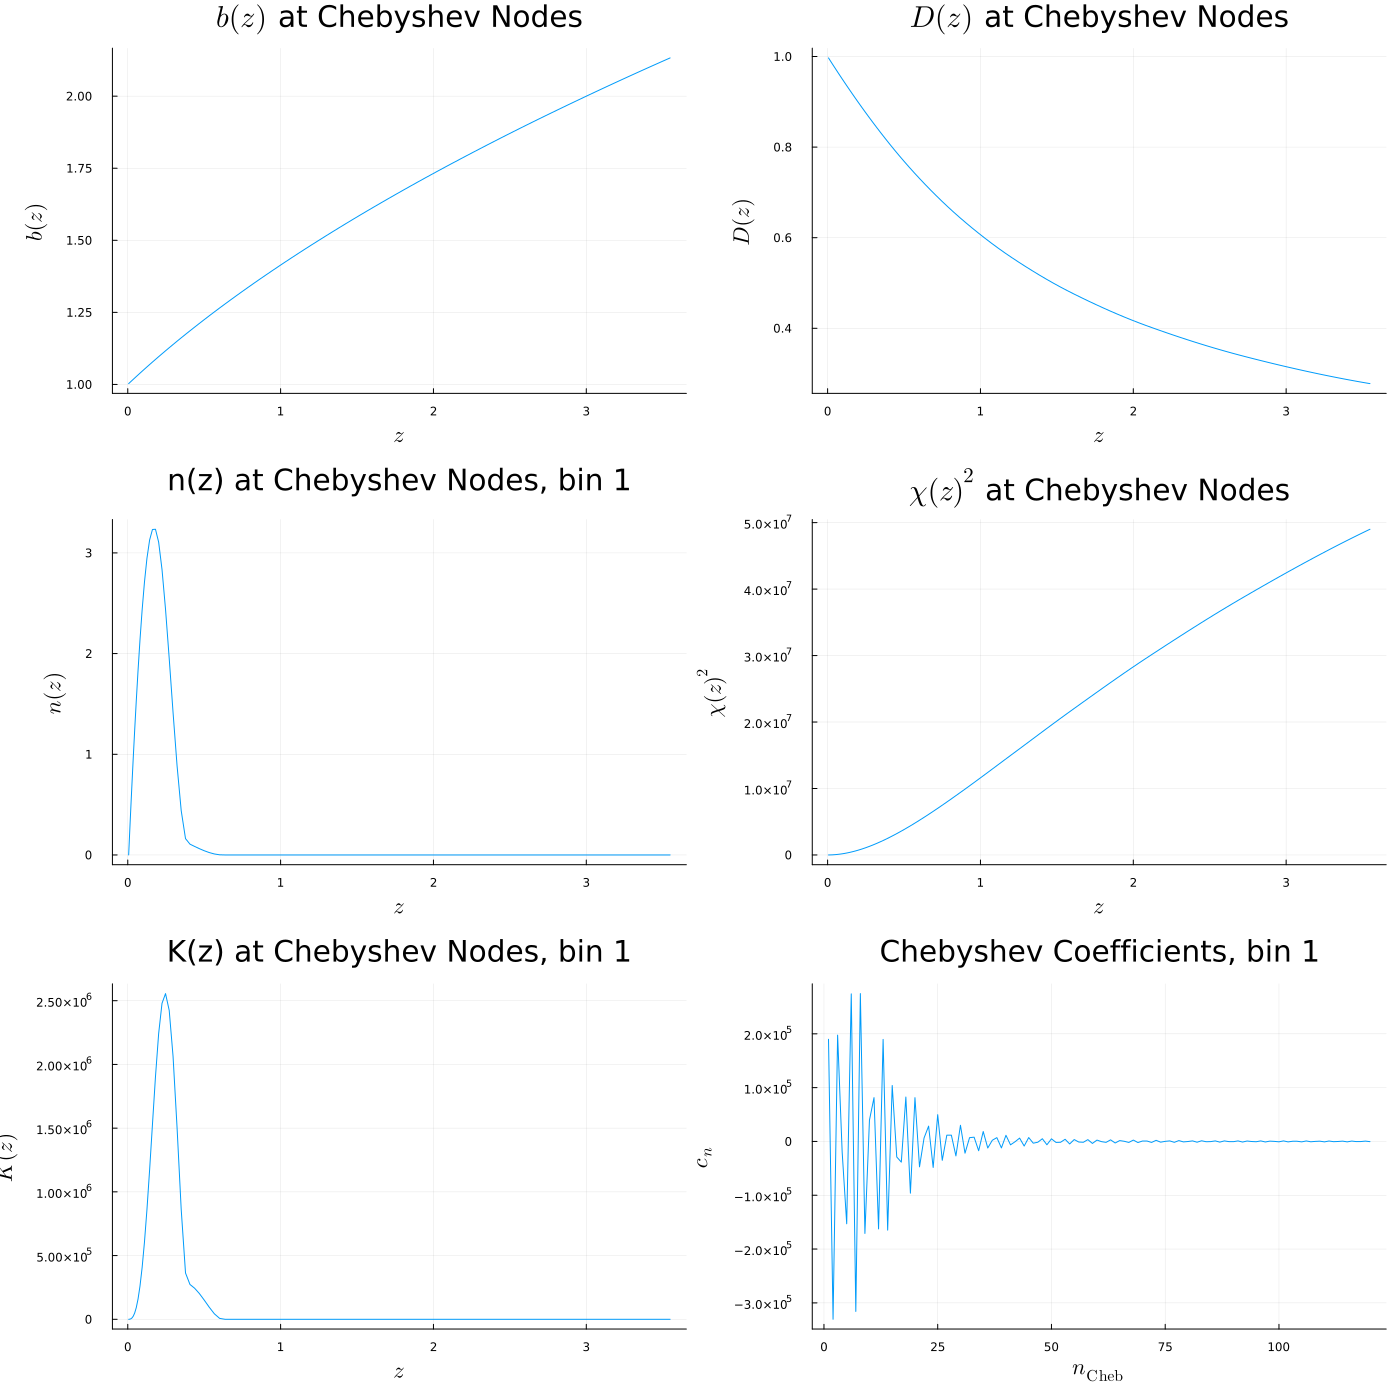

In [36]:
i_bin = 1 # choose a bin to plot

p1 = plot(z_nodes, bias_interp.(z_nodes),
    label = "b(z)",
    xlabel = L"$z$", ylabel = L"$b(z)$",
    title = L"$b(z)$ at Chebyshev Nodes")

p2 = plot(z_nodes, growth_interp.(z_nodes),
    label = "D(z)",
    xlabel = L"$z$", ylabel = L"$D(z)$",
    title = L"$D(z)$ at Chebyshev Nodes")

p3 = plot(z_nodes, nz_interp[i_bin].(z_nodes),
    label = "n(z)",
    xlabel = L"$z$", ylabel = L"$n(z)$",
    title = "n(z) at Chebyshev Nodes, bin $i_bin")

p4 = plot(z_nodes, chi_interp.(z_nodes) .^ 2,
    label = "χ(z)^2",
    xlabel = L"$z$", ylabel = L"$\chi(z)^2$",
    title = L"$\chi(z)^2$ at Chebyshev Nodes")

p5 = plot(z_nodes, K_vals[:, i_bin],
    label = "K(z)",
    xlabel = L"$z$", ylabel = L"$K(z)$",
    title = "K(z) at Chebyshev Nodes, bin $i_bin")

p6 = plot(1:length(cheb_coeff_K[i_bin, :]), cheb_coeff_K[i_bin, :],
    label = "Chebyshev coefficients",
    xlabel = L"$n_{\mathrm{Cheb}}$", ylabel = L"$c_n$",
    title = "Chebyshev Coefficients, bin $i_bin")

plot(p1, p2, p3, p4, p5, p6, layout = (3, 2), size = (1400, 1400),
     legend = false, labelfont = 15, titlefontsize = 20,
     xlabelfontsize = 15, ylabelfontsize = 15)

In [37]:
inv_Hz_array = [1.0 / Blast.compute_adimensional_hubble_factor(z, cosmo) for z in z_range]
inv_Hz_interp = AkimaInterpolation(inv_Hz_array, z_range, extrapolation=ExtrapolationType.Linear)

# ── Evaluate K̃_i(z) = chi^2 * b * D * n_i * (1/H) at Chebyshev nodes ───────
K_tilde_vals = zeros(n_cheb, n_bins)
for i in 1:n_bins, k in 1:n_cheb
    z = z_nodes[k]
    K_tilde_vals[k, i] = chi_interp(z)^2 * bias_interp(z) * growth_interp(z) *
                          nz_interp[i](z) * inv_Hz_interp(z)
end

cheb_coeff_K_tilde = zeros(n_bins, n_cheb)
for i in 1:n_bins
    cheb_coeff_K_tilde[i, :] = fast_chebcoefs_1d(K_tilde_vals[:, i], plan)
end

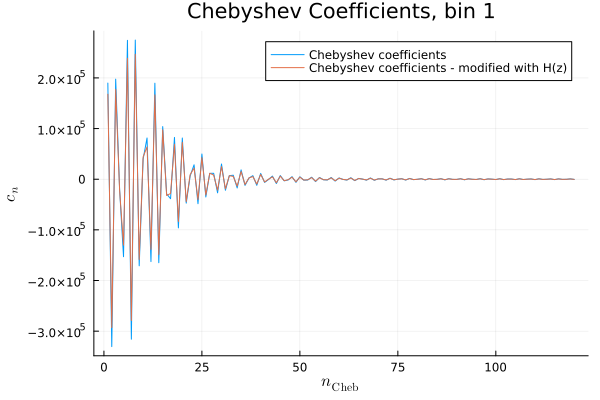

In [38]:
plot(1:length(cheb_coeff_K[i_bin, :]), cheb_coeff_K[i_bin, :],
    label = "Chebyshev coefficients",
    xlabel = L"$n_{\mathrm{Cheb}}$", ylabel = L"$c_n$")

plot!(1:length(cheb_coeff_K_tilde[i_bin, :]), cheb_coeff_K_tilde[i_bin, :],
label = "Chebyshev coefficients - modified with H(z)",
xlabel = L"$n_{\mathrm{Cheb}}$", ylabel = L"$c_n$",
title = "Chebyshev Coefficients, bin $i_bin")

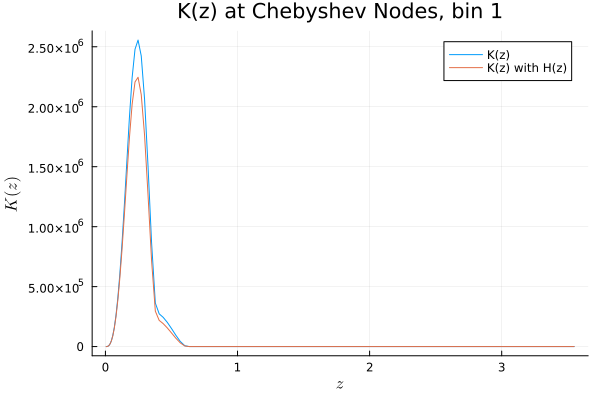

In [39]:
plot(z_nodes, K_vals[:, i_bin],
    label = "K(z)",
    xlabel = L"$z$", ylabel = L"$K(z)$",
    title = "K(z) at Chebyshev Nodes, bin $i_bin")

plot!(z_nodes, K_tilde_vals[:, i_bin],
    label = "K(z) with H(z)",
    xlabel = L"$z$", ylabel = L"$K(z)$")

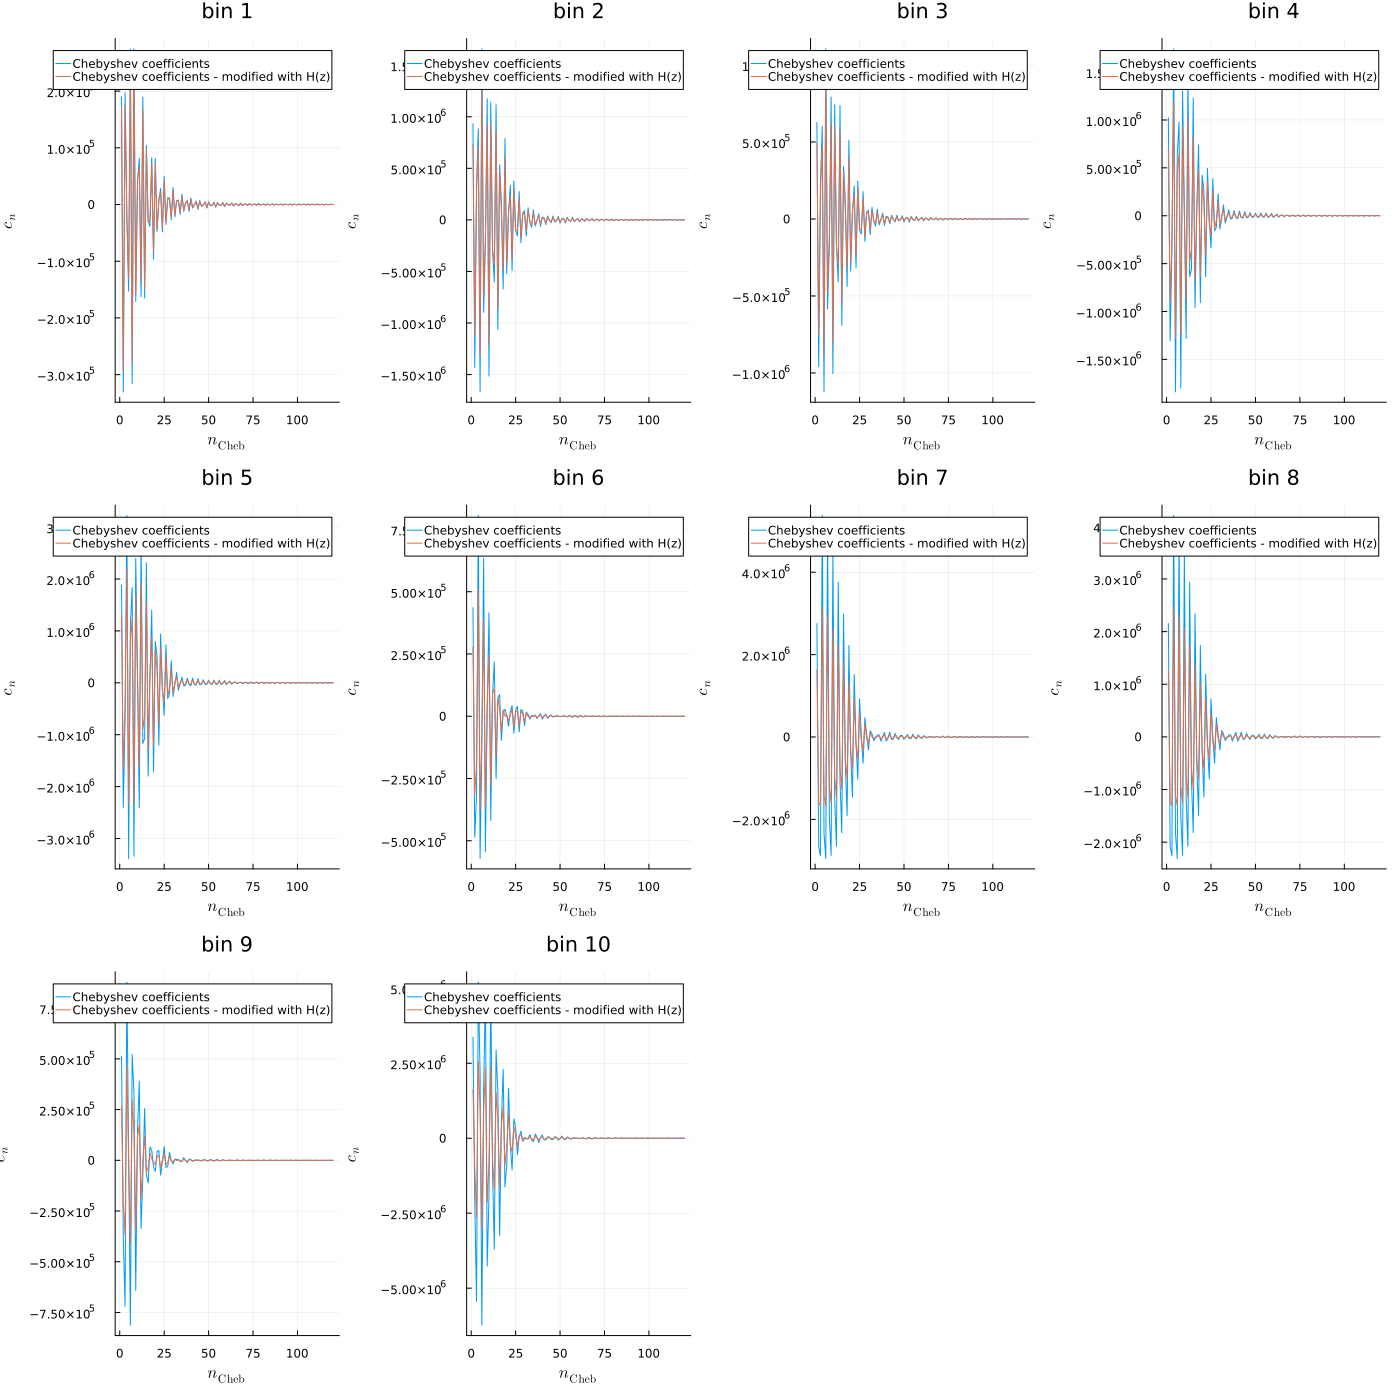

In [40]:
plots = Plots.Plot[]
for i_bin in 1:n_bins
    p = plot(1:length(cheb_coeff_K[i_bin, :]), cheb_coeff_K[i_bin, :],
        label = "Chebyshev coefficients",
        xlabel = L"$n_{\mathrm{Cheb}}$", ylabel = L"$c_n$",
        title = "bin $i_bin")

    plot!(p, 1:length(cheb_coeff_K_tilde[i_bin, :]), cheb_coeff_K_tilde[i_bin, :],
        label = "Chebyshev coefficients - modified with H(z)")

    push!(plots, p)
end

ncols = ceil(Int, sqrt(n_bins))
nrows = ceil(Int, n_bins / ncols)
plot(plots..., layout = (nrows, ncols), size = (1400, 1400))

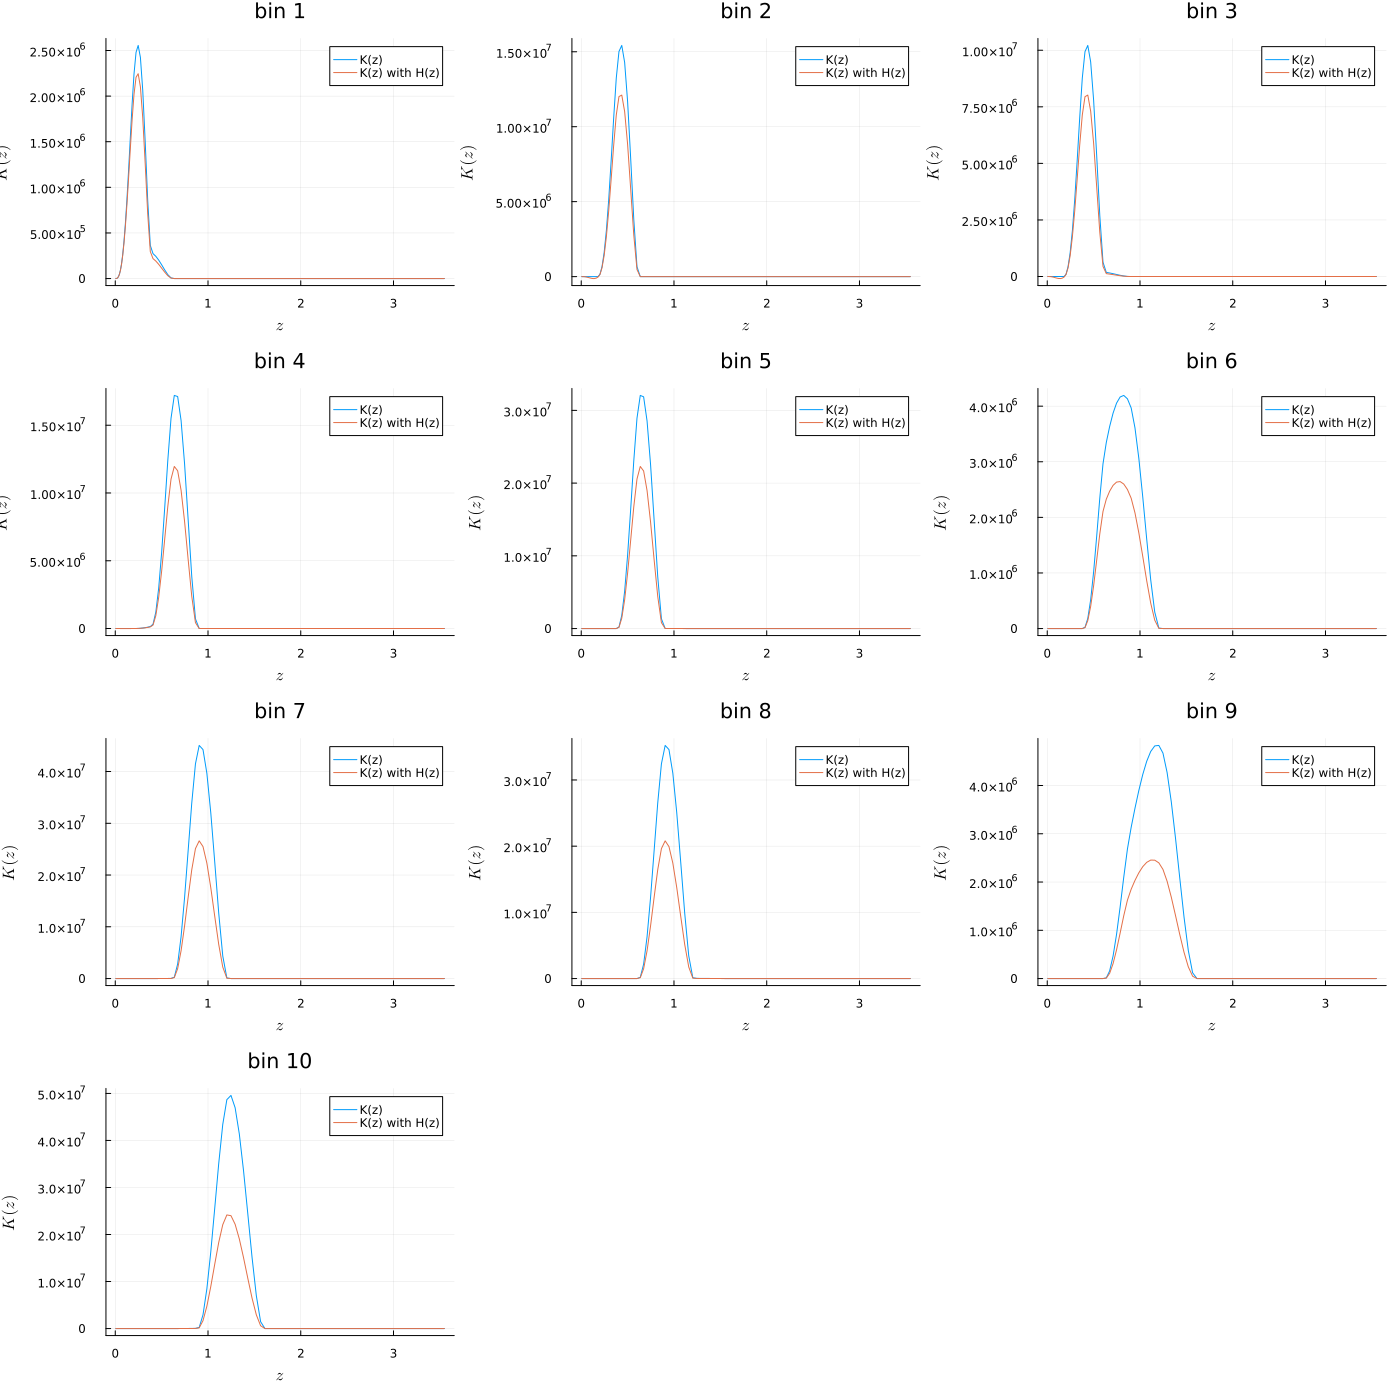

In [41]:
plots = Plots.Plot[]
for i_bin in 1:n_bins
    p = plot(z_nodes, K_vals[:, i_bin],
        label = "K(z)",
        xlabel = L"$z$", ylabel = L"$K(z)$",
        title = "bin $i_bin")

    plot!(p, z_nodes, K_tilde_vals[:, i_bin],
        label = "K(z) with H(z)")

    push!(plots, p)
end

plot(plots..., layout = (ceil(Int, sqrt(n_bins)), ceil(Int, n_bins / ceil(Int, sqrt(n_bins)))), size = (1400, 1400))

In [42]:
println("MIN k = $(minimum(k_array)) || MAX k = $(maximum(k_array)) \n")
println("MIN k1 = $(minimum(k1_array)) || MAX k1 = $(maximum(k1_array)) \n")
println("MIN k2 = $(minimum(k2_array)) || MAX k2 = $(maximum(k2_array)) \n")

MIN k = 0.000357142857142857 || MAX k = 15.38461538461538 

MIN k1 = 0.000357142857142857 || MAX k1 = 15.38461538461538 

MIN k2 = 0.000357142857142857 || MAX k2 = 15.38461538461538 



In [43]:
nk  = length(k_array)
nk1 = length(k1_array)
nk2 = length(k2_array)

W_base_k1 = zeros(Float64, length(ℓ), nk1, nk, n_cheb)
W_base_k2 = zeros(Float64, length(ℓ), nk2, nk, n_cheb)

computation_time = @elapsed begin
    for i in eachindex(ℓ)
        W_base_k1[i, :, :, :] = Blast.compute_W_tilde_modes(ℓ[i], k_array, k1_array, z_nodes, chi_interp, zmin, zmax;
                                                      n_cheb=n_cheb)

        W_base_k2[i, :, :, :] = Blast.compute_W_tilde_modes(ℓ[i], k_array, k2_array, z_nodes, chi_interp, zmin, zmax;
                                                      n_cheb=n_cheb)

        println("step ", i, " completed")
    end
end
println("Total computation time for W_base_k1 and W_base_k2: ", computation_time, " seconds")

step 1 completed
step 2 completed
step 3 completed
step 4 completed
step 5 completed
step 6 completed
step 7 completed
step 8 completed
step 9 completed
step 10 completed
step 11 completed
step 12 completed
step 13 completed
step 14 completed
step 15 completed
step 16 completed
step 17 completed
step 18 completed
step 19 completed
step 20 completed
step 21 completed
step 22 completed
Total computation time for W_base_k1 and W_base_k2: 3007.700276834 seconds


In [44]:
print("Shape of the computed W_tilde: ", size(W_base_k1), "\n")
print("Shape of the computed W_tilde: ", size(W_base_k2), "\n")
print("Shape of the computed cheb_coeff_K_tilde: ", size(cheb_coeff_K_tilde), "\n")

Shape of the computed W_tilde: (22, 121, 121, 120)
Shape of the computed W_tilde: (22, 121, 121, 120)
Shape of the computed cheb_coeff_K_tilde: (10, 120)


In [45]:
W_tilde_k1 = @tullio W[li, b, ik1, ik] := cheb_coeff_K_tilde[b, n] * W_base_k1[li, ik1, ik, n]
W_tilde_k2 = @tullio W[li, b, ik2, ik] := cheb_coeff_K_tilde[b, n] * W_base_k2[li, ik2, ik, n];

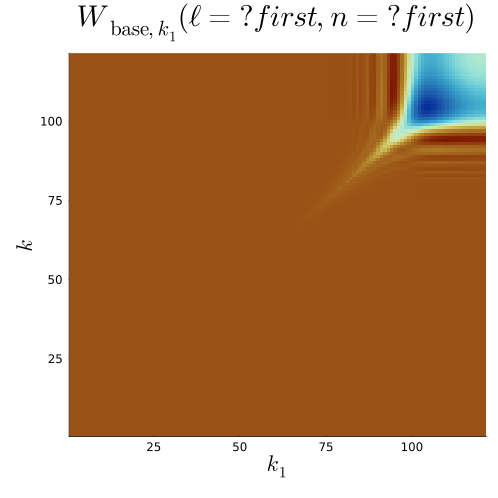

In [46]:
li = 1
nmode = 1

heatmap(1:nk1, 1:nk, W_base_k1[li, :, :, nmode] ./ maximum(abs.(W_base_k1[li, :, :, nmode])),
    size = (500, 500),
    title = L"W_{\mathrm{base},k_1}(\ell=\text{first}, n=\text{first})",
    c = :roma,
    xlabel = L"k_1",
    ylabel = L"k",
    legend = :none,
    yguidefontsize = 15,
    xguidefontsize = 15,
    titlefontsize = 20)

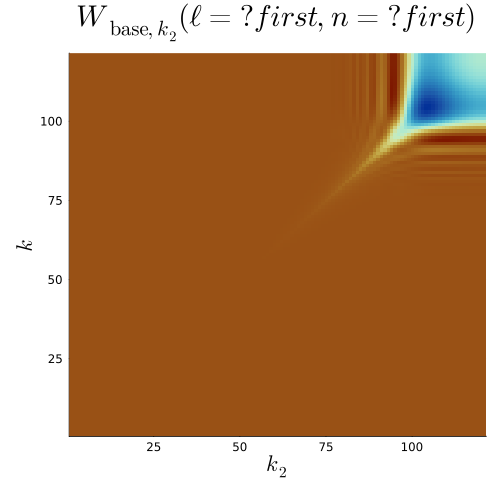

In [47]:
li = 1
nmode = 1

heatmap(1:nk2, 1:nk, W_base_k2[li, :, :, nmode] ./ maximum(abs.(W_base_k1[li, :, :, nmode])),
    size = (500, 500),
    title = L"W_{\mathrm{base},k_2}(\ell=\text{first}, n=\text{first})",
    c = :roma,
    xlabel = L"k_2",
    ylabel = L"k",
    legend = :none,
    yguidefontsize = 15,
    xguidefontsize = 15,
    titlefontsize = 20)

## Now the Power Spectrum

In [48]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

println("Dimension of k points: ", size(k)[1])
println("Dimension of Pklin: ", size(Pklin)[1])
println("Dimension of Pknonlin: ", size(Pknonlin)[1])

#Interpolating the power spectrum
#Linear P(k)
# y has the same length as k, and is a logarithmic range from log10(first(k)) to log10(last(k))
y = LinRange(log10(first(k)),log10(last(k)), length(k))
# x has the same length as z, and is a linear range from first(z) to last(z)
x = LinRange(first(z), last(z), length(z))

# this creates an interpolation of the linear P(k) data. 
# the interpolatio is in log space because P(k) changes by many order or magnitude
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
# this scales the interpolation to the x and y ranges defined above, 
# so that we can evaluate it at any (z, log10(k)) within those ranges
InterpPmm = scale(InterpPmm, (x, y))
# this allows us to extrapolate the interpolation outside of the defined x and y ranges
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k) - similar to the linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables: these functions take in k, χ1, and χ2, 
# and return the square root of the product of the P(k) evaluated at those points.
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

plot(k, power_spectrum.(k, 1000.0, 1000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10,
      size=(800,600),
      legendfontsize=10)


#N5K benchmarks
dtype = Float64

benchmark_gg = npzread("blast_code/data/benchmarks_nl_full_clgg.npz")
benchmark_ll = npzread("blast_code/data/benchmarks_nl_full_clss.npz")
benchmark_gl = npzread("blast_code/data/benchmarks_nl_full_clgs.npz")

#Extracting C_ℓ
gg = dtype.(benchmark_gg["cls"])
ll = dtype.(benchmark_ll["cls"])
gl = dtype.(benchmark_gl["cls"])
ell = dtype.(benchmark_gg["ls"])

#Reshaping them into the same Blast's format
gg_reshaped = zeros( dtype, length(ell), 10, 10)
ll_reshaped = zeros(dtype, length(ell), 5, 5)
gl_reshaped = zeros( dtype, length(ell), 10, 5)
counter = 1
for i in 1:10
    for j in i:10
        gg_reshaped[:,i,j] = gg[counter, :]
        gg_reshaped[:,j,i] = gg_reshaped[:,i,j]
        counter += 1
    end
end
counter = 1
for i in 1:5
    for j in i:5
        ll_reshaped[:,i,j] = ll[counter, :]
        ll_reshaped[:,j,i] = ll_reshaped[:,i,j]
        counter += 1
    end
end
counter = 1
for i in 1:10
    for j in 1:5
        gl_reshaped[:,i,j] = gl[counter, :]
        counter += 1
    end
end

Dimension of k points: 200
Dimension of Pklin: 50
Dimension of Pknonlin: 50


In [49]:
println("Min of k_array: ", minimum(k_array), " || Max of k_array: ", maximum(k_array))

Min of k_array: 0.000357142857142857 || Max of k_array: 15.38461538461538


In [50]:
function compute_Sℓ(W_tilde_k1::AbstractArray,
                    W_tilde_k2::AbstractArray,
                    k_array::AbstractVector,
                    ℓ_list::AbstractVector;
                    normalization::Real = 1.0,
                    χ1::Real = 1000.0,
                    χ2::Real = 1000.0,
                    power_spectrum = power_spectrum)

    nk = length(k_array)

    @assert size(W_tilde_k1, 1) == length(ℓ_list)
    @assert size(W_tilde_k2, 1) == length(ℓ_list)
    @assert size(W_tilde_k1, 2) == size(W_tilde_k2, 2)
    @assert size(W_tilde_k1, 3) == size(W_tilde_k2, 3)
    @assert size(W_tilde_k1, 4) == nk
    @assert size(W_tilde_k2, 4) == nk
    @assert isodd(nk) "Simpson integration requires an odd number of k samples."

    w_k = Blast.simpson_weight_array(nk)
    Δk = nk > 1 ? (last(k_array) - first(k_array)) / (nk - 1) : one(eltype(k_array))

    Pk = power_spectrum.(10 .^ k_array, χ1, χ2)
    integrand = normalization .* k_array.^2 .* Pk .* w_k .* Δk

    @tullio Sℓ[li, b, ik1, ik2] := integrand[m] *
        W_tilde_k1[li, b, ik1, m] *
        W_tilde_k2[li, b, ik2, m]

    return Sℓ
end

compute_Sℓ (generic function with 1 method)

In [51]:
println(length(k_array))
println(isodd(length(k_array)))
nk = 2 * floor(Int, length(k_array) / 2) + 1
k_array = range(first(k_array), last(k_array); length = nk) |> collect
println(size(W_tilde_k1))
println(length(k_array))

121
true
(22, 10, 121, 121)
121


In [52]:
println("min of array x1 = ", minimum(k_array), " || max of array x1 = ", maximum(k_array))

min of array x1 = 0.000357142857142857 || max of array x1 = 15.38461538461538


In [53]:
S_l = compute_Sℓ(
    W_tilde_k1,
    W_tilde_k2,
    k_array,
    ℓ;
    normalization = (2/pi),
    χ1 = x_array[1],
    χ2 = x_array[1],
    power_spectrum = power_spectrum_nl
)

println("Size of S_ell = ", size(S_l))

Size of S_ell = (22, 10, 121, 121)


In [54]:
println("min/max chebcoeffKtilde = ", extrema(cheb_coeff_K_tilde))
println("min/max Kvals = ", extrema(K_tilde_vals))


min/max chebcoeffKtilde = (-3.0369509200500753e6, 3.161285598854146e6)
min/max Kvals = (-128907.66257125635, 2.6604849628145713e7)


In [55]:
println("min/max χ(z)²  = ", extrema(chi_interp.(z_nodes).^2))
println("min/max b(z)   = ", extrema(bias_interp.(z_nodes)))
println("min/max D(z)   = ", extrema(growth_interp.(z_nodes)))
println("min/max 1/H(z) = ", extrema(inv_Hz_interp.(z_nodes)))

# Per ogni bin
for i in 1:n_bins
    println("bin $i → min/max n_i(z) = ", extrema(nz_interp[i].(z_nodes)))
end


min/max χ(z)²  = (676.0, 4.9e7)
min/max b(z)   = (1.0029106651499735, 2.132713006118129)
min/max D(z)   = (0.2777909609205806, 0.996927139848262)
min/max 1/H(z) = (0.18142070974753402, 0.9972355567042289)
bin 1 → min/max n_i(z) = (-1.2030509245831301e-16, 3.2350415852462397)
bin 2 → min/max n_i(z) = (-0.5586718743064978, 5.907587087319381)
bin 3 → min/max n_i(z) = (-0.3791199963828932, 3.910889124792711)
bin 4 → min/max n_i(z) = (-0.005020291143139131, 3.2608837766351644)
bin 5 → min/max n_i(z) = (-4.539491552953301e-6, 6.078681697815812)
bin 6 → min/max n_i(z) = (-5.07149172361203e-10, 0.634318297045195)
bin 7 → min/max n_i(z) = (-1.2612881135023745e-14, 5.154487218939534)
bin 8 → min/max n_i(z) = (-1.6647552455303386e-19, 4.030701258378287)
bin 9 → min/max n_i(z) = (-1.126462547264274e-15, 0.414452121578097)
bin 10 → min/max n_i(z) = (-7.020367129390979e-10, 3.9093201575211585)


c_0 = 3.3640637689078595e6
W_base[n=0] extrema = (-3.3500832442774118e-9, 1.851190044787193e-8)
w0 (solo termine c_0) extrema = (-0.01126989366489894, 0.06227521359031513)
w_full extrema = (-0.0004217047194647205, 0.0011890833353472745)


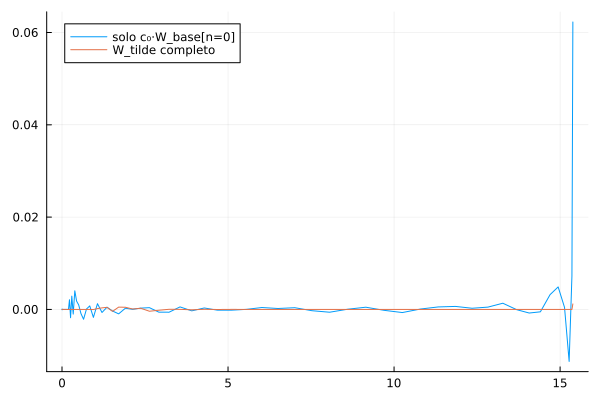

In [56]:
# Solo il termine n=0 (dovrebbe essere positivo e dominante)
i_bin = 10
i_ell = 5

w0 = cheb_coeff_K[i_bin, 1] .* W_base_k1[i_ell, :, 1, 1]  # solo c_0 * W_base[n=0]
w_full = W_tilde_k1[i_ell, i_bin, :, 1]

println("c_0 = ", cheb_coeff_K[i_bin, 1])
println("W_base[n=0] extrema = ", extrema(W_base_k1[i_ell, :, 1, 1]))
println("w0 (solo termine c_0) extrema = ", extrema(w0))
println("w_full extrema = ", extrema(w_full))

plot(k1_array, w0,    label="solo c₀·W_base[n=0]")
plot!(k1_array, w_full, label="W_tilde completo")

In [57]:
# Quante modalità Chebyshev ha W_base?
println("size W_base_k1 = ", size(W_base_k1))   # (nl, nk1, nk, ???)
println("size cheb_coeff_K = ", size(cheb_coeff_K))  # (nbins, ???)

# Devono avere la stessa dimensione lungo n
println("n_cheb W_base = ", size(W_base_k1, 4))
println("n_cheb coeff  = ", size(cheb_coeff_K, 2))


size W_base_k1 = (22, 121, 121, 120)
size cheb_coeff_K = (10, 120)
n_cheb W_base = 120
n_cheb coeff  = 120


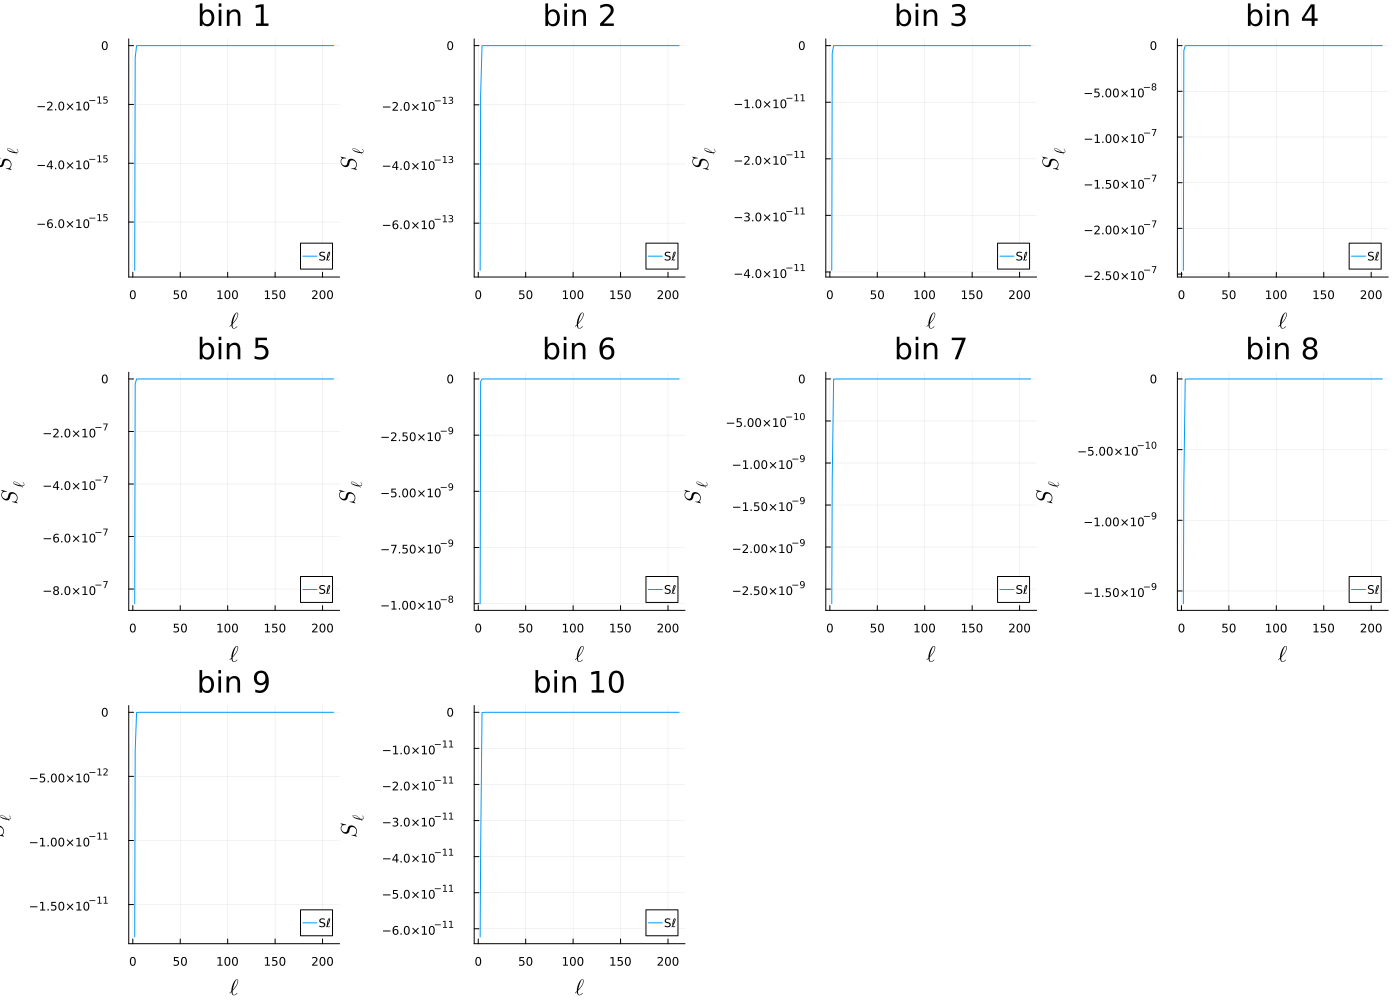

In [58]:
ik1 = 1
ik2 = 1
nl = length(ℓ)

plots = Plots.Plot[]

for i_bin in 1:size(S_l, 2)
    p = plot(ℓ[1:nl], S_l[1:nl, i_bin, ik1, ik2],
             label = "Sℓ",
             title = "bin $i_bin",
             titlefontsize = 20,
             xlabel = L"$\ell$",
             ylabel = L"$S_\ell$",
             labelfontsize = 15)
    push!(plots, p)
end

ncols = ceil(Int, sqrt(size(S_l, 2)))
nrows = ceil(Int, size(S_l, 2) / ncols)

plot(plots..., layout = (nrows, ncols), size = (1400, 1000))

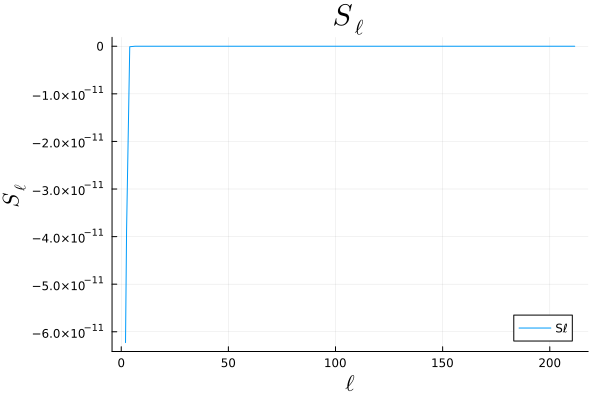

In [59]:
i_bin = 10
ik1 = 1
ik2 = 1
nl = length(ℓ)

plot(ℓ[1:nl], S_l[1:nl, i_bin, ik1, ik2],
     label = "Sℓ",
     title = L"$S_\ell$",
     titlefontsize = 20,
     xlabel = L"$\ell$",
     ylabel = L"$S_\ell$",
     labelfontsize = 15)

In [60]:
function contract_Sℓ(S_l, proj_k1, proj_k2)
    @assert size(S_l, 3) == length(proj_k1)
    @assert size(S_l, 4) == length(proj_k2)

    @tullio C[li, b] := proj_k1[ik1] * S_l[li, b, ik1, ik2] * proj_k2[ik2]
    return C
end

contract_Sℓ (generic function with 1 method)

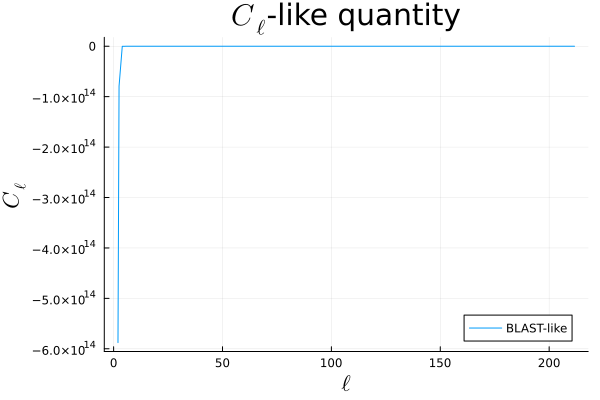

In [61]:
i_bin = 10
nl = length(ℓ)
proj_k1 = ones(size(S_l, 3))
proj_k2 = ones(size(S_l, 4))

C_l_like = contract_Sℓ(S_l, proj_k1, proj_k2)
C_l_like = contract_Sℓ(S_l, proj_k1, proj_k2)

plot(ℓ[1:nl], C_l_like[1:nl, i_bin],
     label = "BLAST-like",
     title = L"$C_\ell$-like quantity",
     titlefontsize = 20,
     xlabel = L"$\ell$",
     ylabel = L"$C_\ell$",
     labelfontsize = 15)